#**Big Sales Prediction using Random Forest Regressor**


##**Get Understanding about Data set**

##**There are 12 variables in dataset**

1.Item_ldentifier

2.Item_Weight

3.Item_Fat_Content

4.Item_Visibility

5.Item_Type

6.Item_MRP

7.Outlet_Identifier

8.Outlet_Establishment_Year

9.Outlet_Size

10.Outlet_Location_Type

11.Outlet_Type

12.Item_Outlet_Sales
















**Import Library**

In [23]:
import pandas as pd

In [24]:
import numpy as np

##**Import CSV as DataFrame**

**Use URL of file directly**

In [25]:
df = pd.read_csv(r'https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Big%20Sales%20Data.csv')

In [26]:
# if wish to use local file 
#df = pd.read_csv(r'Big Sales Data.csv')

In [27]:
##**Get the First Five Rows of the DataFrame** 

In [28]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.3,Low Fat,0.111448,Baking Goods,33.4874,OUT049,1999,Medium,Tier 1,Supermarket Type1,436.608721
1,FDT36,12.3,Low Fat,0.111904,Baking Goods,33.9874,OUT017,2007,Medium,Tier 2,Supermarket Type1,443.127721
2,FDT36,12.3,LF,0.111728,Baking Goods,33.9874,OUT018,2009,Medium,Tier 3,Supermarket Type2,564.598400
3,FDT36,12.3,Low Fat,0.000000,Baking Goods,34.3874,OUT019,1985,Small,Tier 1,Grocery Store,1719.370000
4,FDP12,9.8,Regular,0.045523,Baking Goods,35.0874,OUT017,2007,Medium,Tier 2,Supermarket Type1,352.874000


##**Get Information of DataFrame**

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  str    
 1   Item_Weight                11815 non-null  float64
 2   Item_Fat_Content           14204 non-null  str    
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  str    
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  str    
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                14204 non-null  str    
 9   Outlet_Location_Type       14204 non-null  str    
 10  Outlet_Type                14204 non-null  str    
 11  Item_Outlet_Sales          14204 non-null  float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.3 MB


##**Get Column Names**

In [30]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

##**Get the Summary Statistics**

In [ ]:
df.describe()

##**Get Missing Value Complete**

In [ ]:
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Type')['Item_Weight'].transform('mean')
)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  str    
 1   Item_Weight                14204 non-null  float64
 2   Item_Fat_Content           14204 non-null  str    
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  str    
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  str    
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                14204 non-null  str    
 9   Outlet_Location_Type       14204 non-null  str    
 10  Outlet_Type                14204 non-null  str    
 11  Item_Outlet_Sales          14204 non-null  float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.3 MB


In [34]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,14204.000000,14204.000000,14204.000000,14204.000000,14204.000000
mean,12.790642,0.065953,141.004977,1997.830681,2185.836320
std,4.251186,0.051459,62.086938,8.371664,1827.479550
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.300000,0.027036,94.012000,1987.000000,922.135101
50%,12.800000,0.054021,142.247000,1999.000000,1768.287680
75%,16.000000,0.094037,185.855600,2004.000000,2988.110400
max,30.000000,0.328391,266.888400,2009.000000,31224.726950


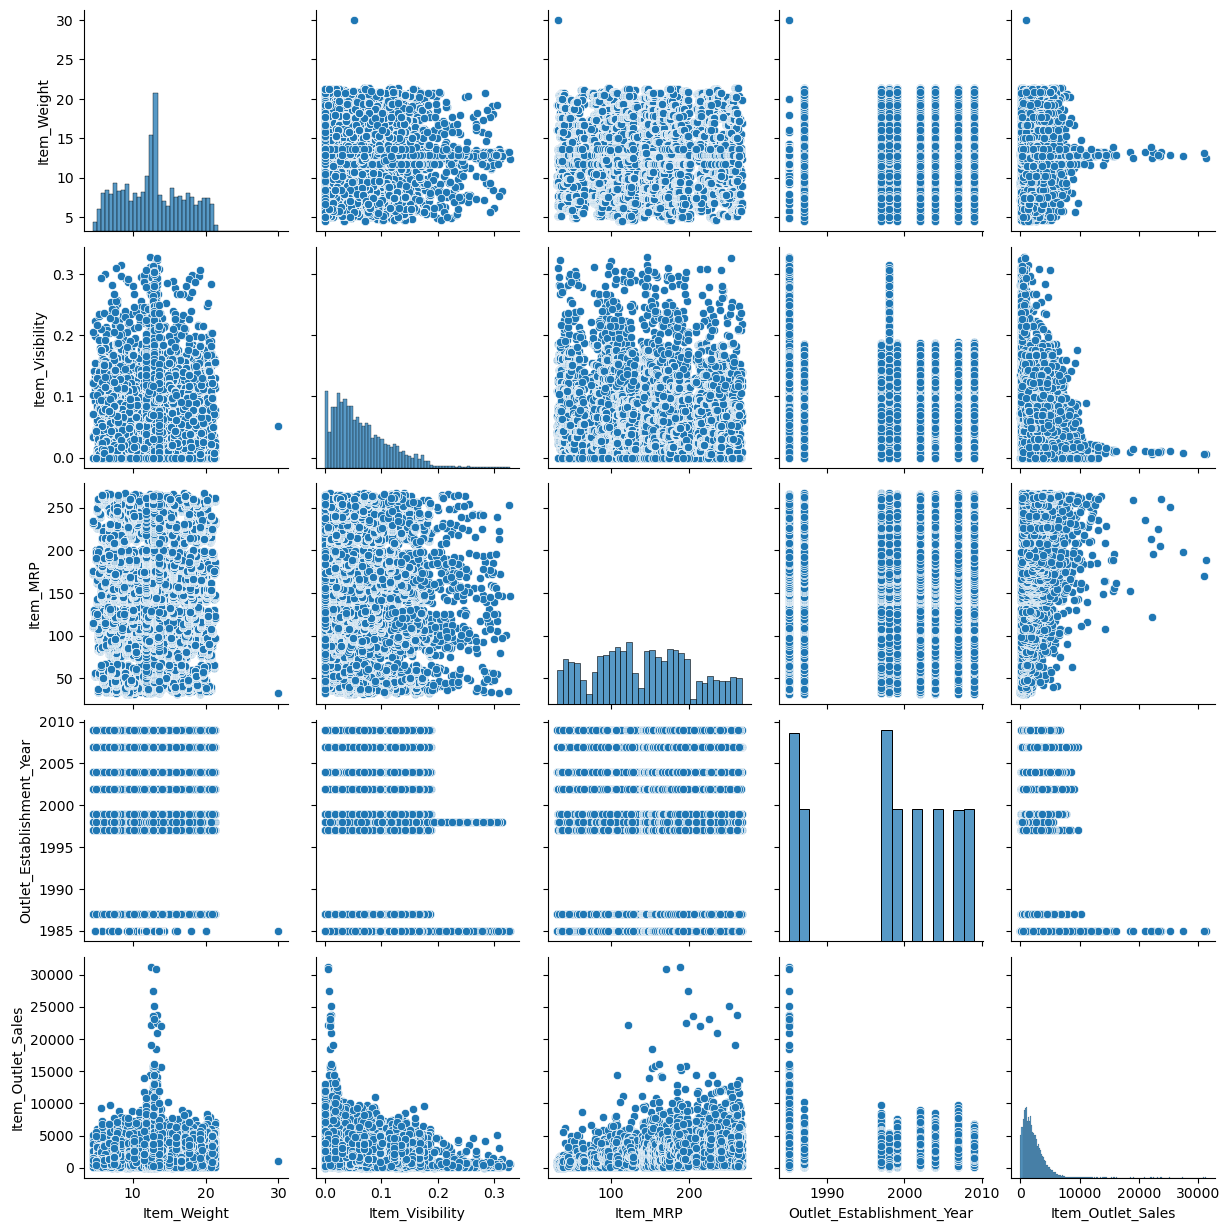

In [35]:
import seaborn as sns
sns.pairplot(df)

##**Get Categories and Count of the categorical Values**

In [36]:
df[['Item_Identifier']].value_counts()

Item_Identifier
FDT36              10
FDM60              10
FDW24              10
FDY24              10
FDL12              10
                   ..
FDS22               7
FDO33               7
FDH58               7
FDM10               7
FDI46               7
Name: count, Length: 1559, dtype: int64

In [37]:
df[['Item_Fat_Content']].value_counts()

Item_Fat_Content
Low Fat             8485
Regular             4824
LF                   522
reg                  195
low fat              178
Name: count, dtype: int64

In [38]:
df.replace({'Item_Fat_Content':{'LF':'Low Fat','reg':'Regular','low fat':'Low Fat'}}, inplace = True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,Low Fat,0.111448,Baking Goods,33.4874,OUT049,1999,Medium,Tier 1,Supermarket Type1,436.608721
1,FDT36,12.300000,Low Fat,0.111904,Baking Goods,33.9874,OUT017,2007,Medium,Tier 2,Supermarket Type1,443.127721
2,FDT36,12.300000,Low Fat,0.111728,Baking Goods,33.9874,OUT018,2009,Medium,Tier 3,Supermarket Type2,564.598400
3,FDT36,12.300000,Low Fat,0.000000,Baking Goods,34.3874,OUT019,1985,Small,Tier 1,Grocery Store,1719.370000
4,FDP12,9.800000,Regular,0.045523,Baking Goods,35.0874,OUT017,2007,Medium,Tier 2,Supermarket Type1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,Low Fat,0.069606,Starchy Foods,261.9252,OUT035,2004,Small,Tier 2,Supermarket Type1,4984.178800
14200,FDG47,12.800000,Low Fat,0.070013,Starchy Foods,262.8252,OUT017,2007,Medium,Tier 2,Supermarket Type1,2885.577200
14201,FDG47,12.800000,Low Fat,0.069561,Starchy Foods,263.0252,OUT013,1987,High,Tier 3,Supermarket Type1,2885.577200
14202,FDG47,13.659758,Low Fat,0.069282,Starchy Foods,263.5252,OUT027,1985,Medium,Tier 3,Supermarket Type3,3803.676434


In [39]:
df[['Item_Fat_Content']].value_counts()

Item_Fat_Content
Low Fat             9185
Regular             5019
Name: count, dtype: int64

In [40]:
df.replace({'Item_Fat_Content' : {'Low Fat' : 0,'Regular':1}},inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,0,0.111448,Baking Goods,33.4874,OUT049,1999,Medium,Tier 1,Supermarket Type1,436.608721
1,FDT36,12.300000,0,0.111904,Baking Goods,33.9874,OUT017,2007,Medium,Tier 2,Supermarket Type1,443.127721
2,FDT36,12.300000,0,0.111728,Baking Goods,33.9874,OUT018,2009,Medium,Tier 3,Supermarket Type2,564.598400
3,FDT36,12.300000,0,0.000000,Baking Goods,34.3874,OUT019,1985,Small,Tier 1,Grocery Store,1719.370000
4,FDP12,9.800000,1,0.045523,Baking Goods,35.0874,OUT017,2007,Medium,Tier 2,Supermarket Type1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,0,0.069606,Starchy Foods,261.9252,OUT035,2004,Small,Tier 2,Supermarket Type1,4984.178800
14200,FDG47,12.800000,0,0.070013,Starchy Foods,262.8252,OUT017,2007,Medium,Tier 2,Supermarket Type1,2885.577200
14201,FDG47,12.800000,0,0.069561,Starchy Foods,263.0252,OUT013,1987,High,Tier 3,Supermarket Type1,2885.577200
14202,FDG47,13.659758,0,0.069282,Starchy Foods,263.5252,OUT027,1985,Medium,Tier 3,Supermarket Type3,3803.676434


In [41]:
df[['Item_Type']].value_counts()

Item_Type            
Fruits and Vegetables    2013
Snack Foods              1989
Household                1548
Frozen Foods             1426
Dairy                    1136
Baking Goods             1086
Canned                   1084
Health and Hygiene        858
Meat                      736
Soft Drinks               726
Breads                    416
Hard Drinks               362
Others                    280
Starchy Foods             269
Breakfast                 186
Seafood                    89
Name: count, dtype: int64

In [42]:
df.replace({'Item_Type':{'Fruits and Vegetables':0,'Snack Foods':0,'Household':1,'Frozen Foods':0,'Dairy':0,'Baking Goods':0,
                         'Canned':0,'Health and Hygiene':1,
                         'Meat':0,'Soft Drinks':0,'Breads':0,'Hard Drinks':0,'Others':2,'Starchy Foods':0,'Breakfast':0,'Seafood':0}},inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,0,0.111448,0,33.4874,OUT049,1999,Medium,Tier 1,Supermarket Type1,436.608721
1,FDT36,12.300000,0,0.111904,0,33.9874,OUT017,2007,Medium,Tier 2,Supermarket Type1,443.127721
2,FDT36,12.300000,0,0.111728,0,33.9874,OUT018,2009,Medium,Tier 3,Supermarket Type2,564.598400
3,FDT36,12.300000,0,0.000000,0,34.3874,OUT019,1985,Small,Tier 1,Grocery Store,1719.370000
4,FDP12,9.800000,1,0.045523,0,35.0874,OUT017,2007,Medium,Tier 2,Supermarket Type1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,0,0.069606,0,261.9252,OUT035,2004,Small,Tier 2,Supermarket Type1,4984.178800
14200,FDG47,12.800000,0,0.070013,0,262.8252,OUT017,2007,Medium,Tier 2,Supermarket Type1,2885.577200
14201,FDG47,12.800000,0,0.069561,0,263.0252,OUT013,1987,High,Tier 3,Supermarket Type1,2885.577200
14202,FDG47,13.659758,0,0.069282,0,263.5252,OUT027,1985,Medium,Tier 3,Supermarket Type3,3803.676434


In [43]:
df[['Item_Type']].value_counts()

Item_Type
0            11518
1             2406
2              280
Name: count, dtype: int64

In [44]:
df[['Outlet_Identifier']].value_counts()

Outlet_Identifier
OUT027               1559
OUT013               1553
OUT049               1550
OUT046               1550
OUT035               1550
OUT045               1548
OUT018               1546
OUT017               1543
OUT010                925
OUT019                880
Name: count, dtype: int64

In [45]:
df.replace({'Outlet_Identifier':{'OUT027' : 0,  
'OUT013' : 1,      
'OUT035' : 4,         
'OUT046' : 3,         
'OUT049' : 2,         
'OUT045' : 5,          
'OUT018' : 6,          
'OUT017' : 7,          
'OUT010' : 8,           
'OUT019' : 9}},inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,0,0.111448,0,33.4874,2,1999,Medium,Tier 1,Supermarket Type1,436.608721
1,FDT36,12.300000,0,0.111904,0,33.9874,7,2007,Medium,Tier 2,Supermarket Type1,443.127721
2,FDT36,12.300000,0,0.111728,0,33.9874,6,2009,Medium,Tier 3,Supermarket Type2,564.598400
3,FDT36,12.300000,0,0.000000,0,34.3874,9,1985,Small,Tier 1,Grocery Store,1719.370000
4,FDP12,9.800000,1,0.045523,0,35.0874,7,2007,Medium,Tier 2,Supermarket Type1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,0,0.069606,0,261.9252,4,2004,Small,Tier 2,Supermarket Type1,4984.178800
14200,FDG47,12.800000,0,0.070013,0,262.8252,7,2007,Medium,Tier 2,Supermarket Type1,2885.577200
14201,FDG47,12.800000,0,0.069561,0,263.0252,1,1987,High,Tier 3,Supermarket Type1,2885.577200
14202,FDG47,13.659758,0,0.069282,0,263.5252,0,1985,Medium,Tier 3,Supermarket Type3,3803.676434


In [46]:
df[['Outlet_Identifier']].value_counts()

Outlet_Identifier
0                    1559
1                    1553
2                    1550
3                    1550
4                    1550
5                    1548
6                    1546
7                    1543
8                     925
9                     880
Name: count, dtype: int64

In [47]:
df[['Outlet_Size']].value_counts()

Outlet_Size
Medium         7122
Small          5529
High           1553
Name: count, dtype: int64

In [48]:
df.replace({'Outlet_Size':{'Small':0,'Medium':1 ,'High':2}},inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,0,0.111448,0,33.4874,2,1999,1,Tier 1,Supermarket Type1,436.608721
1,FDT36,12.300000,0,0.111904,0,33.9874,7,2007,1,Tier 2,Supermarket Type1,443.127721
2,FDT36,12.300000,0,0.111728,0,33.9874,6,2009,1,Tier 3,Supermarket Type2,564.598400
3,FDT36,12.300000,0,0.000000,0,34.3874,9,1985,0,Tier 1,Grocery Store,1719.370000
4,FDP12,9.800000,1,0.045523,0,35.0874,7,2007,1,Tier 2,Supermarket Type1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,0,0.069606,0,261.9252,4,2004,0,Tier 2,Supermarket Type1,4984.178800
14200,FDG47,12.800000,0,0.070013,0,262.8252,7,2007,1,Tier 2,Supermarket Type1,2885.577200
14201,FDG47,12.800000,0,0.069561,0,263.0252,1,1987,2,Tier 3,Supermarket Type1,2885.577200
14202,FDG47,13.659758,0,0.069282,0,263.5252,0,1985,1,Tier 3,Supermarket Type3,3803.676434


In [49]:
df[['Outlet_Size']].value_counts()

Outlet_Size
1              7122
0              5529
2              1553
Name: count, dtype: int64

In [50]:
df[['Outlet_Location_Type']].value_counts()

Outlet_Location_Type
Tier 3                  5583
Tier 2                  4641
Tier 1                  3980
Name: count, dtype: int64

In [51]:
df.replace({'Outlet_Location_Type':{'Tier 1':0,'Tier 2':1 ,'Tier 3':2}},inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,0,0.111448,0,33.4874,2,1999,1,0,Supermarket Type1,436.608721
1,FDT36,12.300000,0,0.111904,0,33.9874,7,2007,1,1,Supermarket Type1,443.127721
2,FDT36,12.300000,0,0.111728,0,33.9874,6,2009,1,2,Supermarket Type2,564.598400
3,FDT36,12.300000,0,0.000000,0,34.3874,9,1985,0,0,Grocery Store,1719.370000
4,FDP12,9.800000,1,0.045523,0,35.0874,7,2007,1,1,Supermarket Type1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,0,0.069606,0,261.9252,4,2004,0,1,Supermarket Type1,4984.178800
14200,FDG47,12.800000,0,0.070013,0,262.8252,7,2007,1,1,Supermarket Type1,2885.577200
14201,FDG47,12.800000,0,0.069561,0,263.0252,1,1987,2,2,Supermarket Type1,2885.577200
14202,FDG47,13.659758,0,0.069282,0,263.5252,0,1985,1,2,Supermarket Type3,3803.676434


In [52]:
df[['Outlet_Location_Type']].value_counts()

Outlet_Location_Type
2                       5583
1                       4641
0                       3980
Name: count, dtype: int64

In [53]:
df[['Outlet_Type']].value_counts()

Outlet_Type      
Supermarket Type1    9294
Grocery Store        1805
Supermarket Type3    1559
Supermarket Type2    1546
Name: count, dtype: int64

In [54]:
df.replace({'Outlet_Type' : { 'Grocery Store':0,'Supermarket Type1':1,'Supermarket Type2':2,'Supermarket Type3': 3 }},inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.300000,0,0.111448,0,33.4874,2,1999,1,0,1,436.608721
1,FDT36,12.300000,0,0.111904,0,33.9874,7,2007,1,1,1,443.127721
2,FDT36,12.300000,0,0.111728,0,33.9874,6,2009,1,2,2,564.598400
3,FDT36,12.300000,0,0.000000,0,34.3874,9,1985,0,0,0,1719.370000
4,FDP12,9.800000,1,0.045523,0,35.0874,7,2007,1,1,1,352.874000
...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDG47,12.800000,0,0.069606,0,261.9252,4,2004,0,1,1,4984.178800
14200,FDG47,12.800000,0,0.070013,0,262.8252,7,2007,1,1,1,2885.577200
14201,FDG47,12.800000,0,0.069561,0,263.0252,1,1987,2,2,1,2885.577200
14202,FDG47,13.659758,0,0.069282,0,263.5252,0,1985,1,2,3,3803.676434


In [55]:
df[['Outlet_Type']].value_counts()

Outlet_Type
1              9294
0              1805
3              1559
2              1546
Name: count, dtype: int64

In [56]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDT36,12.3,0,0.111448,0,33.4874,2,1999,1,0,1,436.608721
1,FDT36,12.3,0,0.111904,0,33.9874,7,2007,1,1,1,443.127721
2,FDT36,12.3,0,0.111728,0,33.9874,6,2009,1,2,2,564.598400
3,FDT36,12.3,0,0.000000,0,34.3874,9,1985,0,0,0,1719.370000
4,FDP12,9.8,1,0.045523,0,35.0874,7,2007,1,1,1,352.874000


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  str    
 1   Item_Weight                14204 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                14204 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          14204 non-null  float64
dtypes: float64(4), int64(1), object(6), str(1)
memory usage: 1.3+ MB


##**Get Shape of the DataFrame**

In [58]:
df.shape

(14204, 12)

##**Define y(dependent or label or Target Variable)and X (independent or features or attribute variable)**

In [59]:
y = df['Item_Outlet_Sales']

In [60]:
y.shape

(14204,)

In [61]:
y

0         436.608721
1         443.127721
2         564.598400
3        1719.370000
4         352.874000
            ...     
14199    4984.178800
14200    2885.577200
14201    2885.577200
14202    3803.676434
14203    3644.354765
Name: Item_Outlet_Sales, Length: 14204, dtype: float64

In [62]:
X = df.drop(['Item_Identifier','Item_Outlet_Sales'],axis=1)

In [63]:
X.shape

(14204, 10)

In [64]:
X

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,12.300000,0,0.111448,0,33.4874,2,1999,1,0,1
1,12.300000,0,0.111904,0,33.9874,7,2007,1,1,1
2,12.300000,0,0.111728,0,33.9874,6,2009,1,2,2
3,12.300000,0,0.000000,0,34.3874,9,1985,0,0,0
4,9.800000,1,0.045523,0,35.0874,7,2007,1,1,1
...,...,...,...,...,...,...,...,...,...,...
14199,12.800000,0,0.069606,0,261.9252,4,2004,0,1,1
14200,12.800000,0,0.070013,0,262.8252,7,2007,1,1,1
14201,12.800000,0,0.069561,0,263.0252,1,1987,2,2,1
14202,13.659758,0,0.069282,0,263.5252,0,1985,1,2,3


##**Get X variables Standardized**

standardization of datasets is a common requirement for many manchine learning estimators implemented in scikit-learn; they might behave badly if the individual features do not more or less look like standard normally distributed data:Gaussian with zero mean and unit variance.


In [67]:
from sklearn.preprocessing import StandardScaler

In [68]:
sc = StandardScaler()

In [69]:
X_std = df[['Item_Weight','Item_Visibility','Item_MRP','Outlet_Establishment_Year' ]]

In [70]:
X_std = sc.fit_transform(X_std)

In [71]:
X_std

array([[-0.11541705,  0.88413635, -1.73178716,  0.13968068],
       [-0.11541705,  0.89300616, -1.72373366,  1.09531886],
       [-0.11541705,  0.88958331, -1.72373366,  1.3342284 ],
       ...,
       [ 0.00220132,  0.07011952,  1.96538148, -1.29377659],
       [ 0.20444792,  0.06469366,  1.97343499, -1.53268614],
       [ 0.00220132,  0.07334891,  1.97504569,  0.13968068]],
      shape=(14204, 4))

In [72]:
X[['Item_Weight','Item_Visibility','Item_MRP','Outlet_Establishment_Year' ]] = pd.DataFrame(X_std,columns = [['Item_Weight','Item_Visibility','Item_MRP','Outlet_Establishment_Year' ]])

In [73]:
X

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,-0.115417,0,0.884136,0,-1.731787,2,0.139681,1,0,1
1,-0.115417,0,0.893006,0,-1.723734,7,1.095319,1,1,1
2,-0.115417,0,0.889583,0,-1.723734,6,1.334228,1,2,2
3,-0.115417,0,-1.281712,0,-1.717291,9,-1.532686,0,0,0
4,-0.703509,1,-0.397031,0,-1.706016,7,1.095319,1,1,1
...,...,...,...,...,...,...,...,...,...,...
14199,0.002201,0,0.070990,0,1.947664,4,0.736955,0,1,1
14200,0.002201,0,0.078898,0,1.962160,7,1.095319,1,1,1
14201,0.002201,0,0.070120,0,1.965381,1,-1.293777,2,2,1
14202,0.204448,0,0.064694,0,1.973435,0,-1.532686,1,2,3


##**Get Train Test Split**

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1,random_state = 2529)

In [76]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12783, 10), (1421, 10), (12783,), (1421,))

##**Get Model Train**

In [78]:
from sklearn.ensemble import RandomForestRegressor

In [79]:
rfr = RandomForestRegressor(random_state=2529)

In [80]:
rfr.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

##**Get Model Prediction**

In [81]:
y_pred = rfr.predict(X_test)

In [82]:
y_pred.shape

(1421,)

In [83]:
y_pred

array([1445.29507934,  669.51312572, 1883.54185796, ..., 2228.46101734,
       3251.93307564,  460.5156873 ], shape=(1421,))

# **Get Model Evaluation**

In [84]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [85]:
mean_squared_error(y_test,y_pred)

1611351.4218735117

In [86]:
mean_absolute_error(y_test,y_pred)

828.4427522913378

In [87]:
r2_score(y_test,y_pred)

0.5805891490212769

##**Get Visualization of Actual Vs Predicted Results**

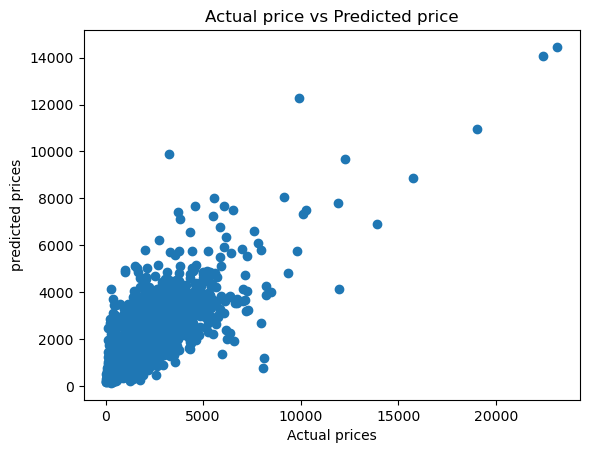

In [88]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("Actual prices")
plt.ylabel("predicted prices")
plt.title("Actual price vs Predicted price")
plt.show()